# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading Data

In [2]:
df = pd.read_excel("data_cleaned_prossesed.xlsx")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Batch-Factor         1000 non-null   int64 
 1   Factor               1000 non-null   int64 
 2   Downtime_Minutes     1000 non-null   int64 
 3   Batch                1000 non-null   int64 
 4   Description          1000 non-null   object
 5   Operator_Error       1000 non-null   int64 
 6   Date                 1000 non-null   object
 7   Product              1000 non-null   object
 8   Operator             1000 non-null   object
 9   Start Time           1000 non-null   object
 10  End Time             1000 non-null   object
 11  Flavor               1000 non-null   object
 12  Size                 1000 non-null   int64 
 13  Min batch time       1000 non-null   int64 
 14  Start-Time           1000 non-null   object
 15  End-Time             1000 non-null   object
 16  Fact-Mi

# Adding Calculated Columns

In [3]:
df["Net_Production_time"] = df['Fact-Min-batch-time'] - df['Downtime_Minutes']
df['Efficiency'] = (df['Min batch time'] / df['Net_Production_time']).round(2)

In [5]:
df.head()

,Batch-Factor,Factor,Downtime_Minutes,Batch,Description,Operator_Error,Date,Product,Operator,Start Time,End Time,Flavor,Size,Min batch time,Start-Time,End-Time,Fact-Min-batch-time,Net_Production_time,Efficiency
0,5000014,4,9,500001,Inventory shortage,0,1/1/2025,DC-600,frank,00:00:00,01:09:00,diet cola,600,60,00:00,01:09,69,60,1.00
1,5000044,4,10,500004,Inventory shortage,0,1/1/2025,DC-600,charlie,03:47:00,04:57:00,diet cola,600,60,03:47,04:57,70,60,1.00
2,5000036,6,21,500003,Machine adjustment,1,1/1/2025,LE-600,charlie,02:09:00,03:47:00,lemon lime,600,60,02:09,03:47,98,77,0.78
3,5000037,7,17,500003,Machine failure,0,1/1/2025,LE-600,charlie,02:09:00,03:47:00,lemon lime,600,60,02:09,03:47,98,81,0.74
4,5000071,1,28,500007,Emergency stop,0,1/1/2025,CO-2L,dennis,09:59:00,12:45:00,cola,2000,98,09:59,12:45,166,138,0.71


In [4]:
df['Actual Working Ratio'] = (df['Net_Production_time'] / df['Fact-Min-batch-time']).round(2)
df['over time'] = df['Fact-Min-batch-time'] - df['Min batch time']


In [25]:
df.head()

,Batch-Factor,Factor,Downtime_Minutes,Batch,Description,Operator_Error,Date,Product,Operator,Start Time,...,Flavor,Size,Min batch time,Start-Time,End-Time,Fact-Min-batch-time,Net_Production_time,Efficiency,Actual Working Ratio,over time
0,5000014,4,9,500001,Inventory shortage,0,1/1/2025,DC-600,frank,00:00:00,...,diet cola,600,60,00:00,01:09,69,60,1.00,0.87,9
1,5000044,4,10,500004,Inventory shortage,0,1/1/2025,DC-600,charlie,03:47:00,...,diet cola,600,60,03:47,04:57,70,60,1.00,0.86,10
2,5000036,6,21,500003,Machine adjustment,1,1/1/2025,LE-600,charlie,02:09:00,...,lemon lime,600,60,02:09,03:47,98,77,0.78,0.79,38
3,5000037,7,17,500003,Machine failure,0,1/1/2025,LE-600,charlie,02:09:00,...,lemon lime,600,60,02:09,03:47,98,81,0.74,0.83,38
4,5000071,1,28,500007,Emergency stop,0,1/1/2025,CO-2L,dennis,09:59:00,...,cola,2000,98,09:59,12:45,166,138,0.71,0.83,68


In [5]:
Total_ideal_time = df['Min batch time'].sum()
Total_net_production_time = df['Net_Production_time'].sum()
Performance_ratio = (Total_ideal_time / Total_net_production_time).round(2)
print("Performance Ratio:", Performance_ratio)

Performance Ratio: 0.74


In [7]:
df["Downtime_Ratio"] = (df['Downtime_Minutes'] / df['Fact-Min-batch-time']).round(2)
df["Performance_loss"]= df["Min batch time"] - df["Net_Production_time"]
df["Is_Efficient"] = np.where(df["Efficiency"] >= 1, "1", "0")

In [9]:
df.head()

,Batch-Factor,Factor,Downtime_Minutes,Batch,Description,Operator_Error,Date,Product,Operator,Start Time,...,Start-Time,End-Time,Fact-Min-batch-time,Net_Production_time,Efficiency,Actual Working Ratio,over time,Downtime_Ratio,Performance_loss,Is_Efficient
0,5000014,4,9,500001,Inventory shortage,0,1/1/2025,DC-600,frank,00:00:00,...,00:00,01:09,69,60,1.00,0.87,9,0.13,0,1
1,5000044,4,10,500004,Inventory shortage,0,1/1/2025,DC-600,charlie,03:47:00,...,03:47,04:57,70,60,1.00,0.86,10,0.14,0,1
2,5000036,6,21,500003,Machine adjustment,1,1/1/2025,LE-600,charlie,02:09:00,...,02:09,03:47,98,77,0.78,0.79,38,0.21,-17,0
3,5000037,7,17,500003,Machine failure,0,1/1/2025,LE-600,charlie,02:09:00,...,02:09,03:47,98,81,0.74,0.83,38,0.17,-21,0
4,5000071,1,28,500007,Emergency stop,0,1/1/2025,CO-2L,dennis,09:59:00,...,09:59,12:45,166,138,0.71,0.83,68,0.17,-40,0


# Answering Questions

In [9]:
print("Efficiency Ratio mean:", df['Efficiency'].mean().round(2))
print("Efficiency Ratio median:", df['Efficiency'].median().round(2))
print("Efficiency Ratio std dev:", df['Efficiency'].std().round(2))

Efficiency Ratio mean: 0.76
Efficiency Ratio median: 0.74
Efficiency Ratio std dev: 0.16


In [10]:
print("Perfomance Ratio:", Performance_ratio)

Perfomance Ratio: 0.74


In [12]:
result = df.loc[(df['Efficiency'] > 0.9) & (df['Downtime_Minutes'] < 10)].groupby('Flavor').size()
best_flavor = result.idxmax()
print(f"Best Flavor: {best_flavor} (Count: {result[best_flavor]})")

# Or to also get the best batch:
best_data = df.loc[(df['Efficiency'] > 0.9) & (df['Downtime_Minutes'] < 10)].sort_values('Efficiency', ascending=False).iloc[0]
print(f"Best Batch: {best_data['Batch']}")
print(f"Best Flavor: {best_flavor}")

Best Flavor: cola (Count: 10)
Best Batch: 500001
Best Flavor: cola


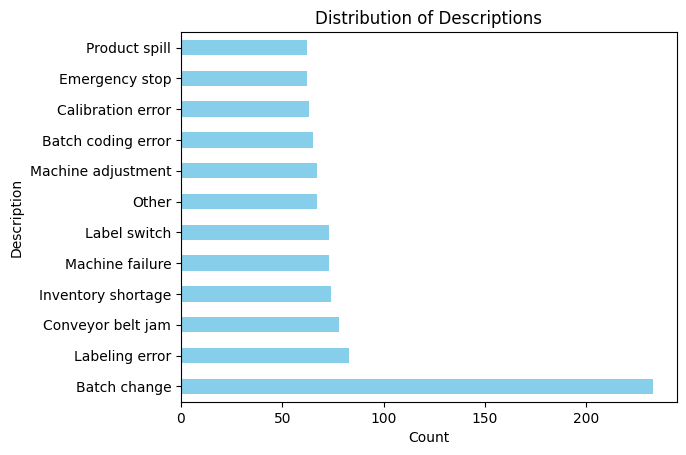

In [6]:
df['Description'].value_counts().plot(kind='barh', color='skyblue')
plt.title('Distribution of Descriptions')
plt.ylabel('Description')
plt.xlabel('Count')
plt.show()

<Axes: xlabel='Product'>

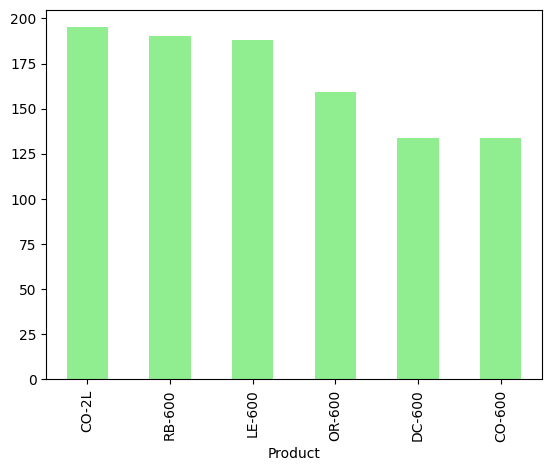

In [8]:
df['Product'].value_counts().plot(kind='bar', color='lightgreen')

<Axes: >

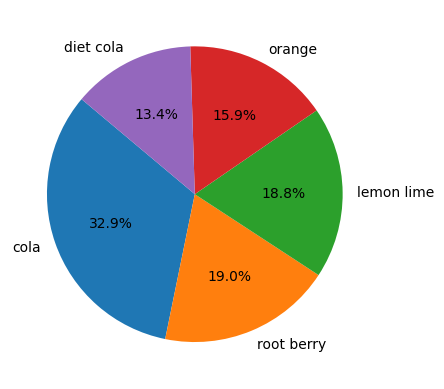

In [17]:
df['Flavor'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, ylabel='')

<Axes: >

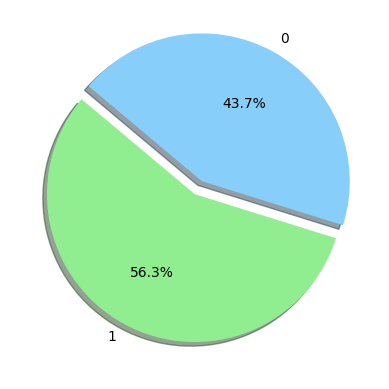

In [16]:
#1 : no error  0 : error
df["Operator_Error"].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['lightgreen', 'lightskyblue'], explode=[0, 0.1], shadow=True, ylabel='')

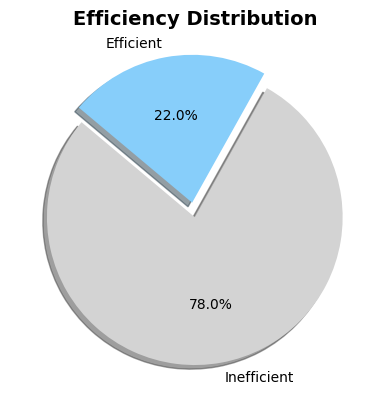

In [21]:
df["Is_Efficient"].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['lightgray', 'lightskyblue'], explode=[0, 0.1], shadow=True, ylabel='', labels=['Inefficient', 'Efficient'])
plt.title('Efficiency Distribution', fontsize=14, fontweight='bold')
plt.show()


<Axes: ylabel='Operator'>

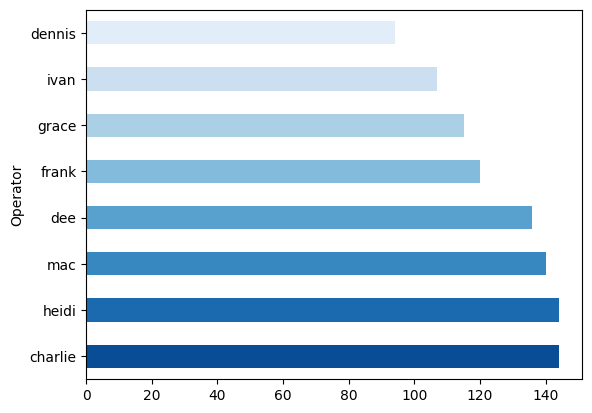

In [20]:
df['Operator'].value_counts().plot(kind='barh', color=sns.color_palette('Blues_r', len(df['Operator'].unique())))

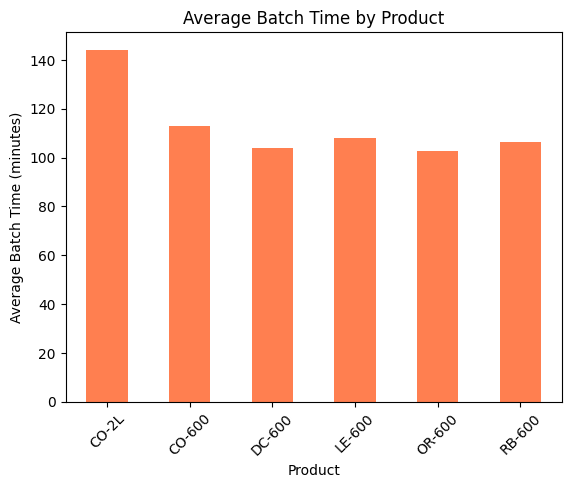

In [15]:
df.groupby("Product")['Fact-Min-batch-time'].mean().plot(kind='bar', color='coral')
plt.xlabel('Product')
plt.ylabel('Average Batch Time (minutes)')
plt.title('Average Batch Time by Product')
plt.xticks(rotation=45)
plt.show()

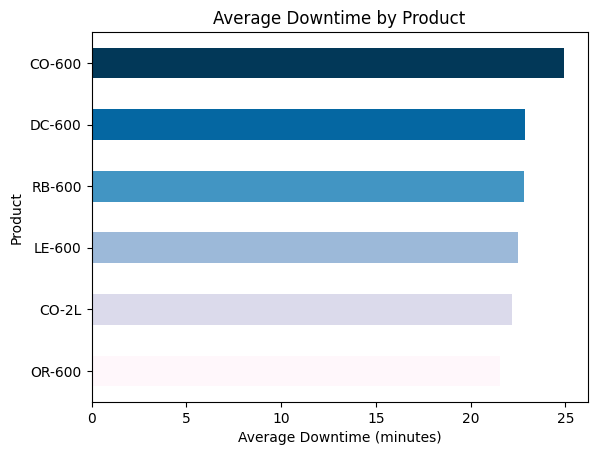

In [ ]:
df.groupby("Product")['Downtime_Minutes'].mean().sort_values().plot(kind='barh', color= plt.cm.PuBu(np.linspace(0, 1, len(df['Product'].unique()))))
plt.xlabel('Average Downtime (minutes)')
plt.ylabel('Product')
plt.title('Average Downtime by Product')
plt.show()

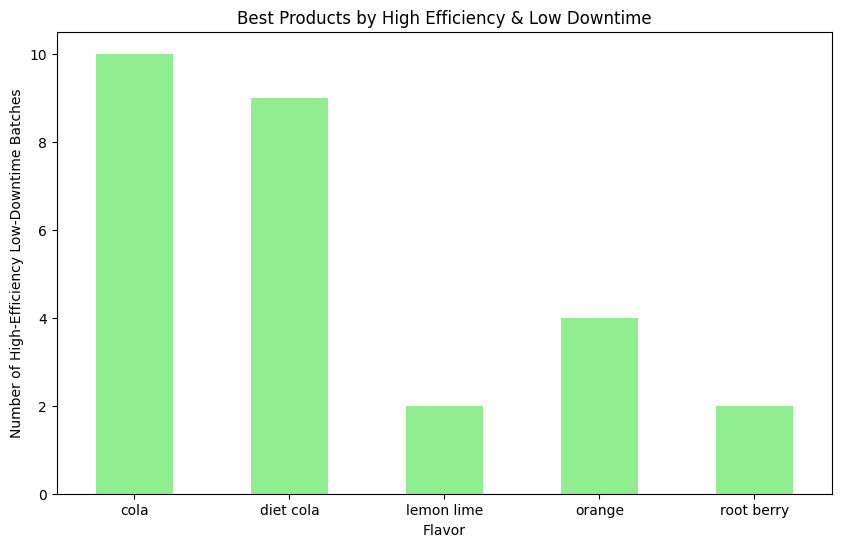

In [20]:
best_products = df[(df['Efficiency'] > 0.9) & (df['Downtime_Minutes'] < 10)]
product_counts = best_products.groupby('Flavor').size()

plt.figure(figsize=(10,6))
product_counts.plot(kind='bar', color='lightgreen')
plt.xlabel('Flavor')
plt.xticks(rotation=0)
plt.ylabel('Number of High-Efficiency Low-Downtime Batches')
plt.title('Best Products by High Efficiency & Low Downtime')
plt.show()


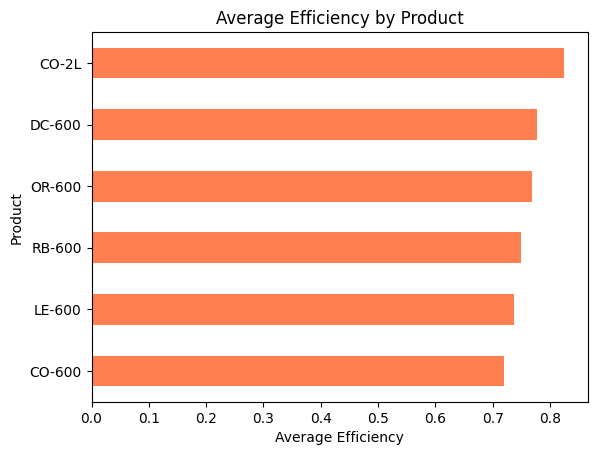

In [53]:
df.groupby('Product')["Efficiency"].mean().sort_values().plot(kind='barh', color='coral')
plt.xlabel('Average Efficiency')
plt.ylabel('Product')
plt.title('Average Efficiency by Product')
plt.show()

In [21]:
error_rate = df.groupby('Operator')['Operator_Error'].mean().sort_values(ascending=False)
print(error_rate)


Operator
dennis     0.670213
ivan       0.635514
charlie    0.583333
grace      0.565217
dee        0.551471
heidi      0.541667
frank      0.533333
mac        0.471429
Name: Operator_Error, dtype: float64


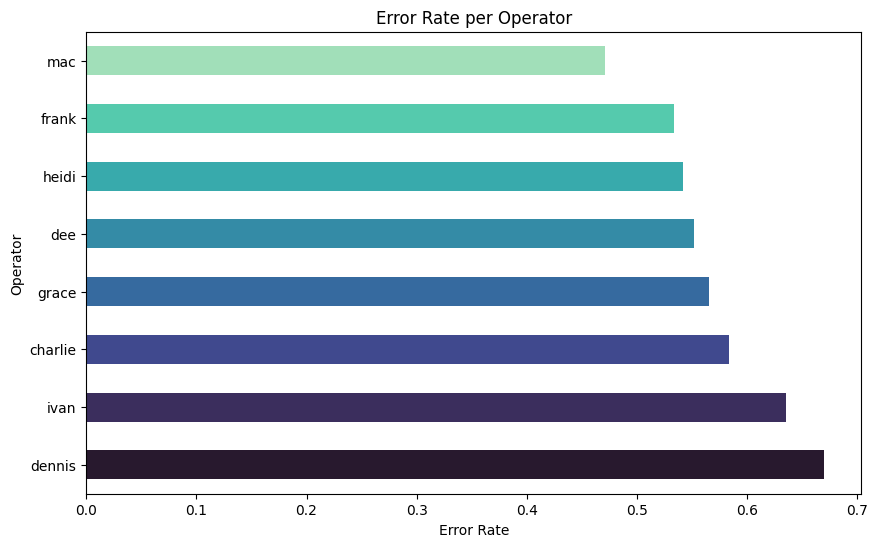

In [27]:
plt.figure(figsize=(10,6))
error_rate.plot(kind='barh', color=sns.color_palette("mako", len(error_rate)))
plt.xlabel('Error Rate')
plt.ylabel('Operator')
plt.title('Error Rate per Operator')
plt.show()

Text(0.5, 1.0, 'Average Efficiency by Operator')

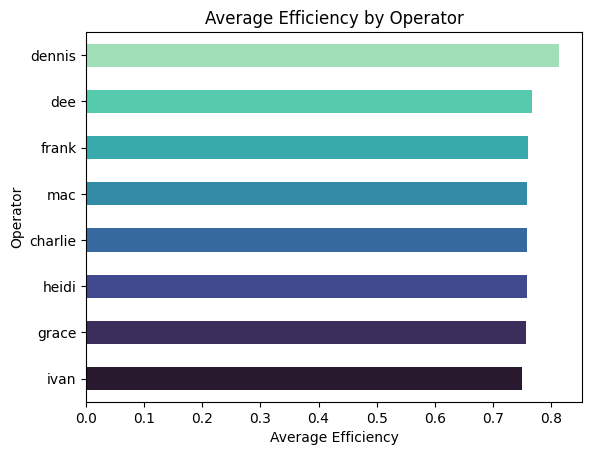

In [54]:
df.groupby("Operator")["Efficiency"].mean().sort_values().plot(kind='barh', color=sns.color_palette("mako", len(df['Operator'].unique())))
plt.xlabel('Average Efficiency')
plt.ylabel('Operator')
plt.title('Average Efficiency by Operator')

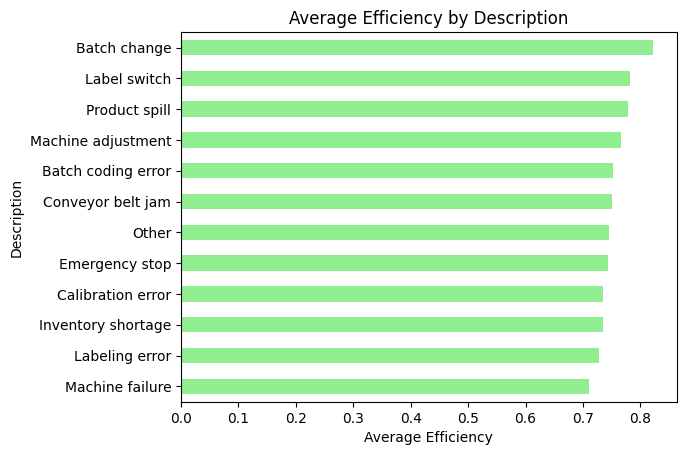

In [55]:
df.groupby("Description")['Efficiency'].mean().sort_values().plot(kind='barh', color='lightgreen')
plt.xlabel('Average Efficiency')
plt.ylabel('Description')
plt.title('Average Efficiency by Description')
plt.show()

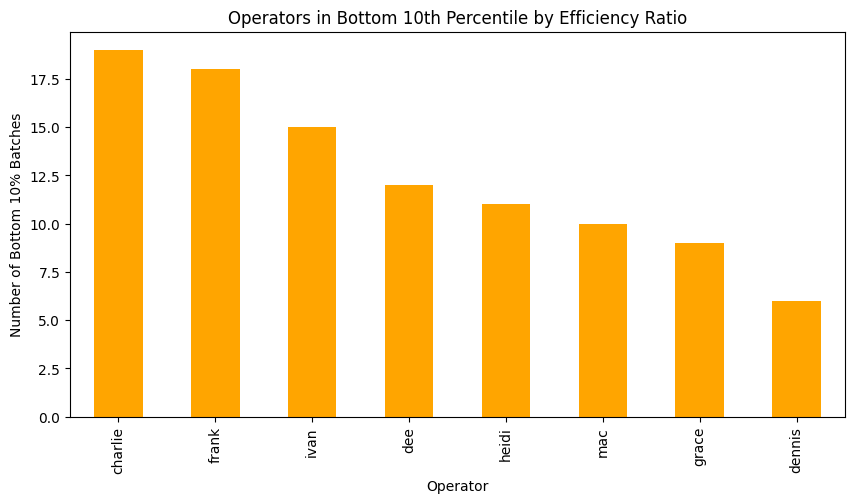

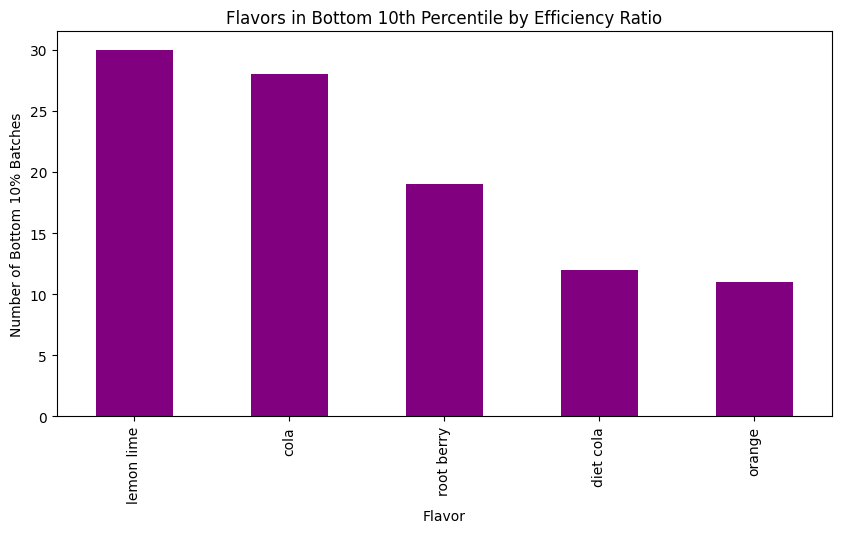

In [28]:
threshold = df['Efficiency'].quantile(0.1)
low_efficiency_batches = df[df['Efficiency'] <= threshold]
operator_low_efficiency = low_efficiency_batches['Operator'].value_counts()
flavor_low_efficiency = low_efficiency_batches['Flavor'].value_counts()

plt.figure(figsize=(10,5))
operator_low_efficiency.plot(kind='bar', color='orange')
plt.xlabel('Operator')
plt.ylabel('Number of Bottom 10% Batches')
plt.title('Operators in Bottom 10th Percentile by Efficiency Ratio')
plt.show()

plt.figure(figsize=(10,5))
flavor_low_efficiency.plot(kind='bar', color='purple')
plt.xlabel('Flavor')
plt.ylabel('Number of Bottom 10% Batches')
plt.title('Flavors in Bottom 10th Percentile by Efficiency Ratio')
plt.show()

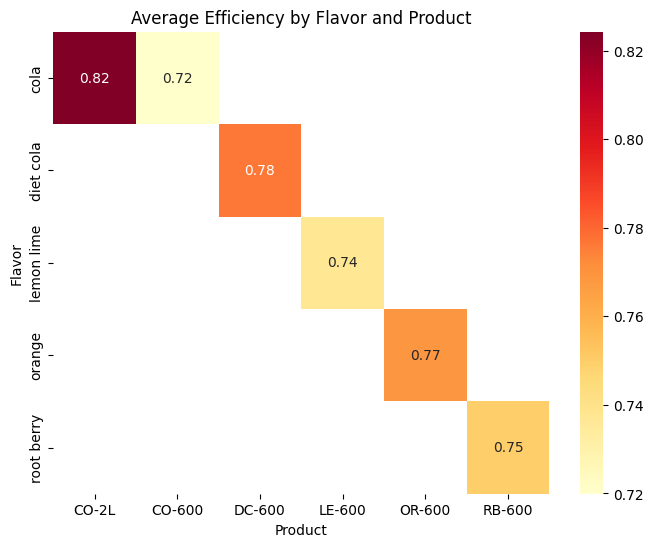

In [79]:
pivot_table = df.pivot_table(
    index='Flavor',             
    columns='Product',         
    values='Efficiency',        
    aggfunc='mean'           
)

# رسم Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlOrRd')
plt.title('Average Efficiency by Flavor and Product')
plt.xlabel('Product')
plt.ylabel('Flavor')
plt.show()

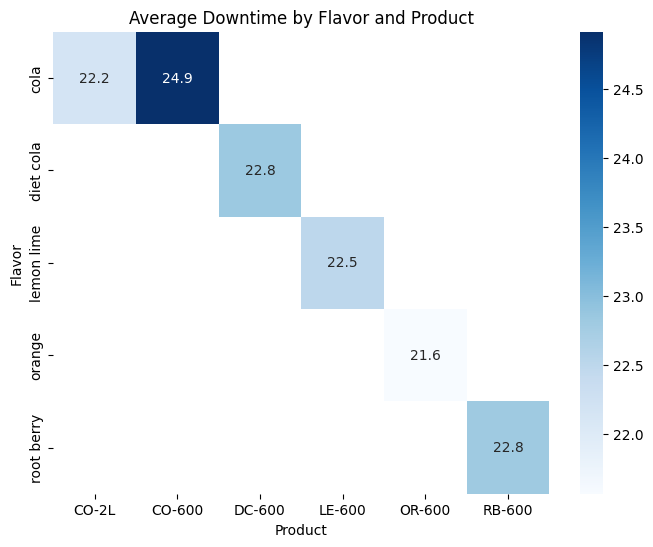

In [81]:
pivot_table_dt = df.pivot_table(
    index='Flavor',
    columns='Product',
    values='Downtime_Minutes',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table_dt, annot=True, fmt=".1f", cmap='Blues')
plt.title('Average Downtime by Flavor and Product')
plt.xlabel('Product')
plt.ylabel('Flavor')
plt.show()


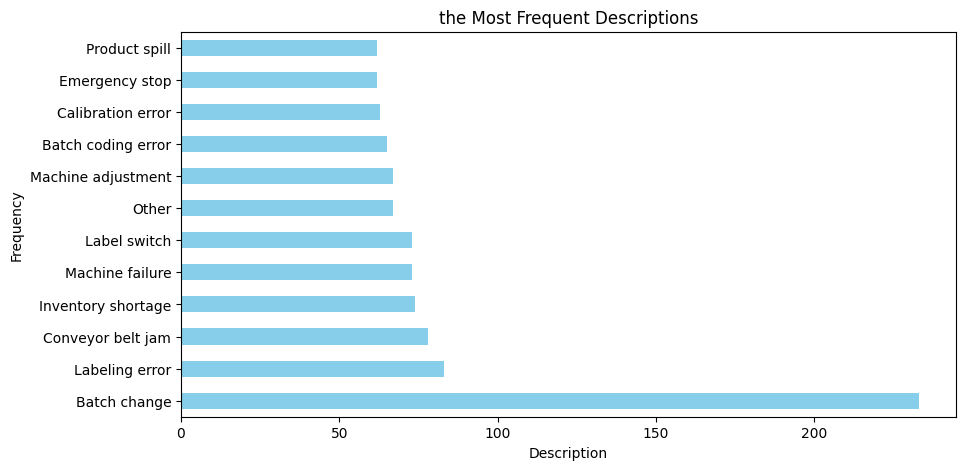

In [ ]:
desc_freq = df['Description'].value_counts()
plt.figure(figsize=(10,5))
desc_freq.plot(kind='barh', color='skyblue')
plt.ylabel('Description')
plt.xlabel('Frequency')
plt.title('the Most Frequent Descriptions')
plt.xticks(rotation=0)
plt.show()

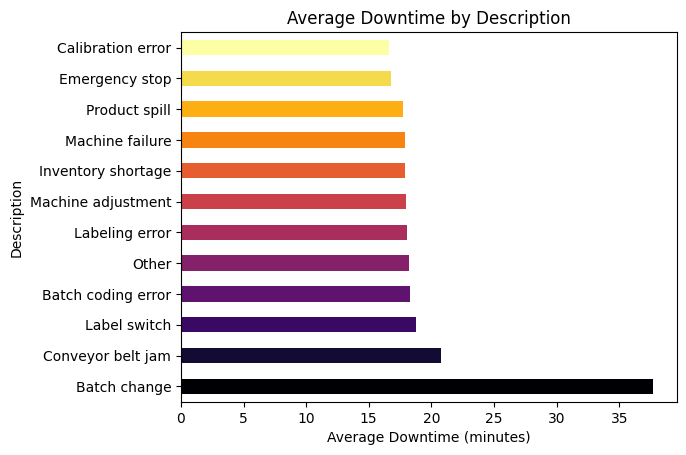

In [25]:
df.groupby("Description")['Downtime_Minutes'].mean().sort_values(ascending=False).plot(kind='barh', color=plt.cm.inferno(np.linspace(0, 1, len(df['Description'].unique()))))
plt.xlabel('Average Downtime (minutes)')
plt.ylabel('Description')
plt.title('Average Downtime by Description')
plt.show()

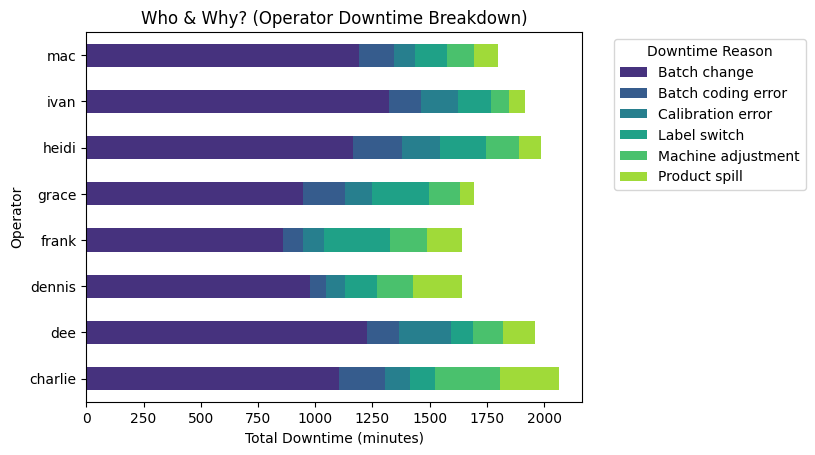

In [44]:
df.loc[df['Operator_Error']== 1].groupby(['Operator','Description'])['Downtime_Minutes'].sum().sort_values(ascending=False).unstack().plot(kind='barh',stacked=True, color=sns.color_palette("viridis", 6))
plt.xlabel('Total Downtime (minutes)')
plt.ylabel('Operator')
plt.title('Who & Why? (Operator Downtime Breakdown)')
plt.legend(title='Downtime Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

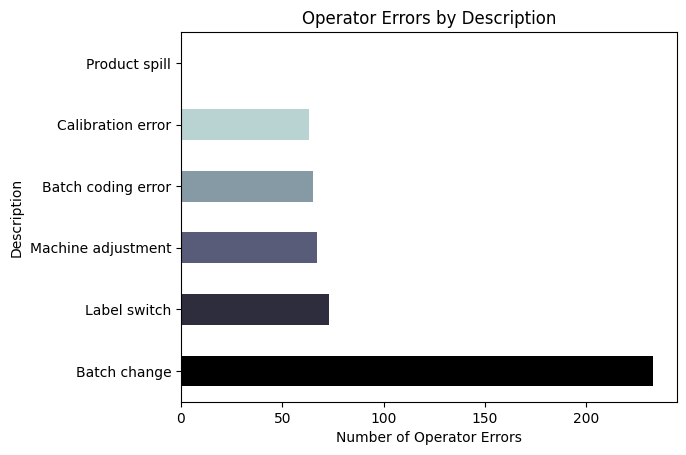

In [50]:
# count descriptions where an operator error occurred, then plot
desc_counts = df.loc[df['Operator_Error'] == 1, 'Description'].value_counts()
colors = plt.cm.bone(np.linspace(0, 1, len(desc_counts)))
desc_counts.plot(kind='barh', color=colors)
plt.xlabel('Number of Operator Errors')
plt.ylabel('Description')
plt.title('Operator Errors by Description')
plt.show()

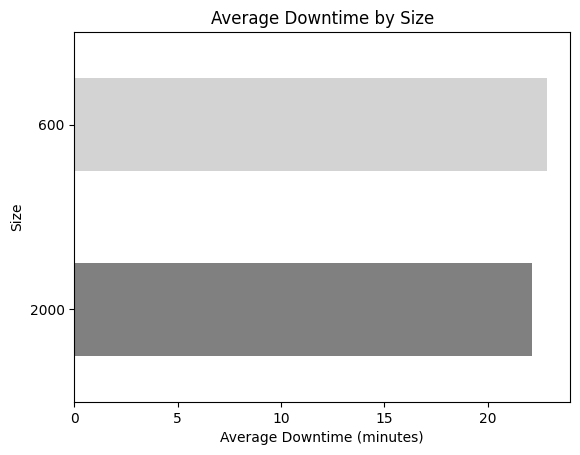

In [47]:
df.groupby("Size")["Downtime_Minutes"].mean().sort_values().plot(kind='barh', color= ['gray','lightgray'])
plt.xlabel('Average Downtime (minutes)')
plt.ylabel('Size')
plt.title('Average Downtime by Size')
plt.show()

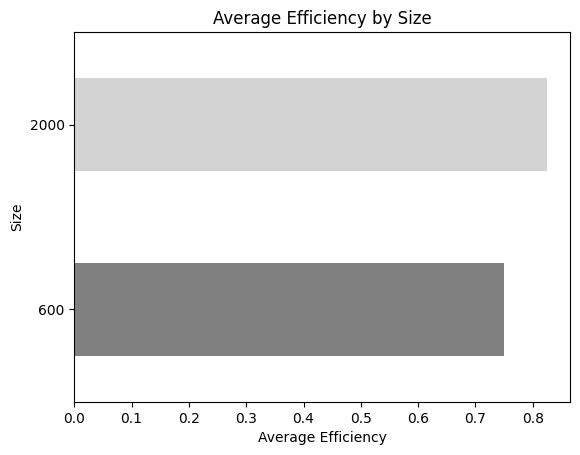

In [52]:
df.groupby("Size")["Efficiency"].mean().sort_values().plot(kind='barh', color= ['gray','lightgray'])
plt.xlabel('Average Efficiency')
plt.ylabel('Size')
plt.title('Average Efficiency by Size')
plt.show()

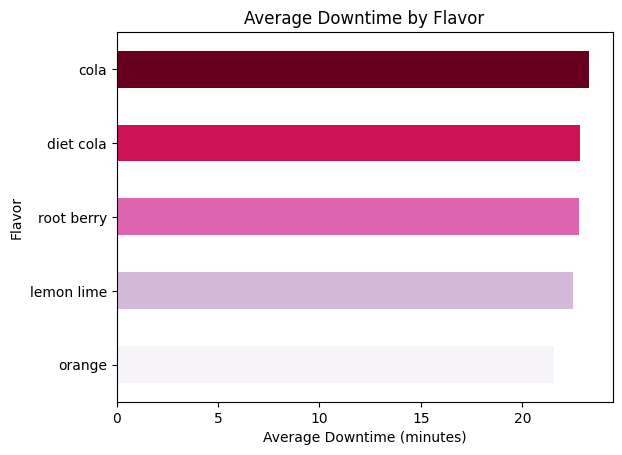

In [48]:
df.groupby("Flavor")["Downtime_Minutes"].mean().sort_values().plot(kind='barh', color= plt.cm.PuRd(np.linspace(0, 1, len(df['Flavor'].unique()))))
plt.xlabel('Average Downtime (minutes)')
plt.ylabel('Flavor')
plt.title('Average Downtime by Flavor')
plt.show()

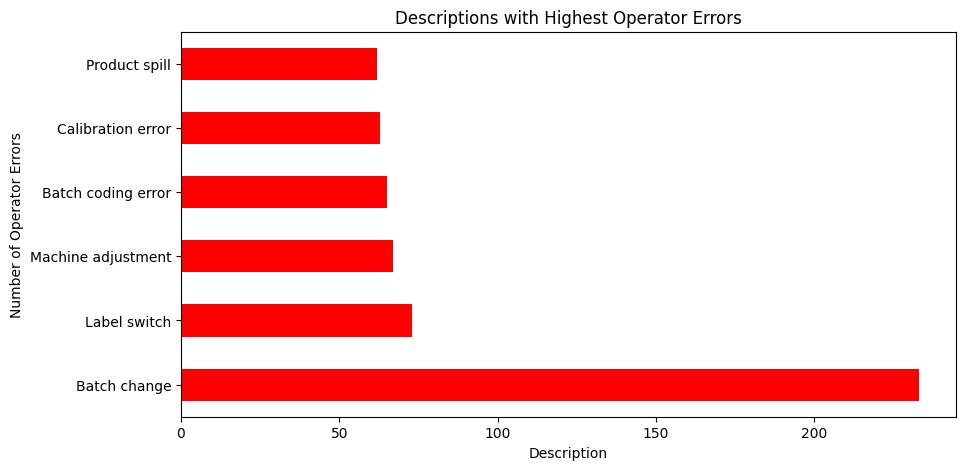

In [43]:
desc_operator_error_counts = df.loc[df['Operator_Error'] == 1, 'Description'].value_counts()
plt.figure(figsize=(10,5))
desc_operator_error_counts.plot(kind='barh', color='red')
plt.xlabel('Description')
plt.ylabel('Number of Operator Errors')
plt.title('Descriptions with Highest Operator Errors')
plt.show()

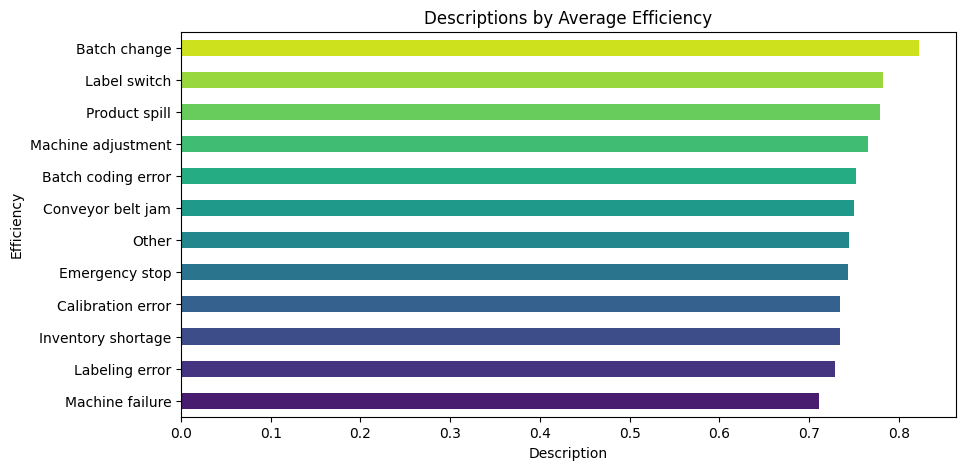

In [44]:
desc_efficiency = df.groupby('Description')['Efficiency'].mean().sort_values()
plt.figure(figsize=(10,5))
desc_efficiency.plot(kind='barh', color=sns.color_palette("viridis", len(desc_efficiency)))
plt.xlabel('Description')
plt.ylabel('Efficiency')
plt.title('Descriptions by Average Efficiency')
plt.show()

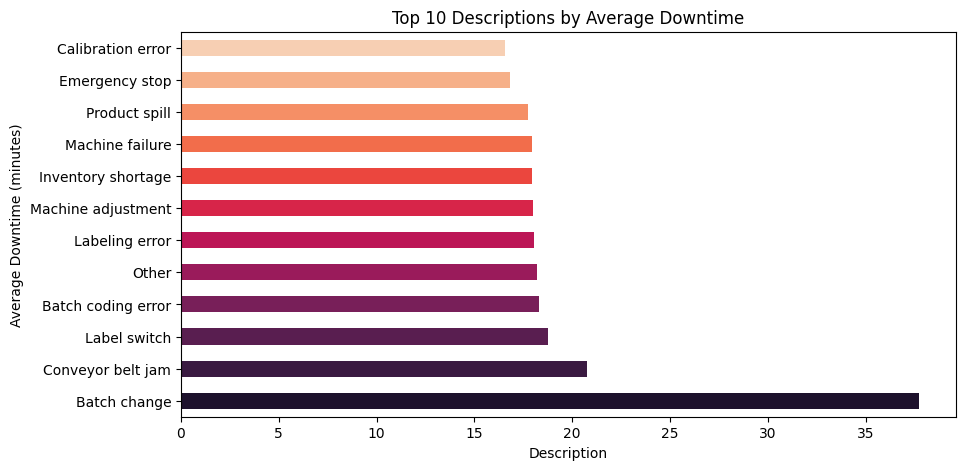

In [47]:
desc_downtime = df.groupby('Description')['Downtime_Minutes'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
desc_downtime.plot(kind='barh', color=sns.color_palette("rocket", len(desc_downtime)))
plt.xlabel('Description')
plt.ylabel('Average Downtime (minutes)')
plt.title('Top 10 Descriptions by Average Downtime')

plt.show()

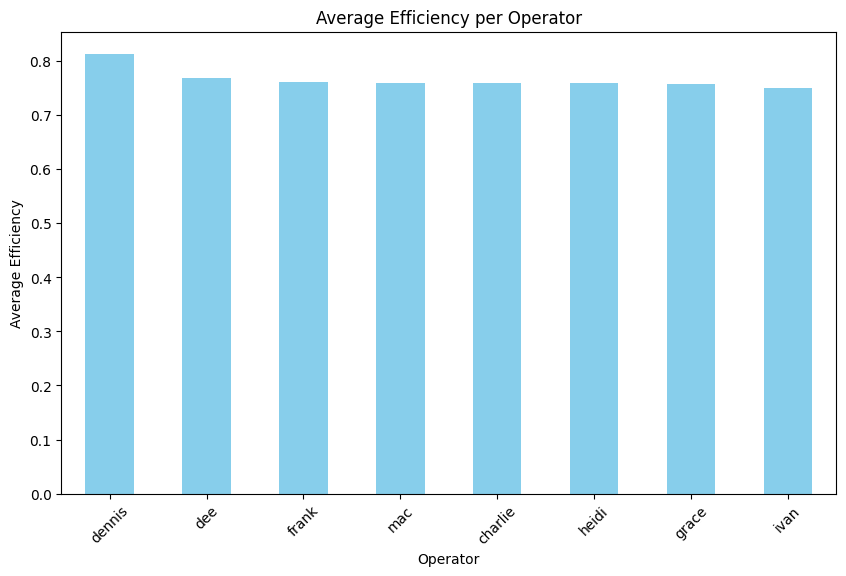

In [45]:
operator_efficiency = df.groupby('Operator')['Efficiency'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
operator_efficiency.plot(kind='bar', color='skyblue')
plt.xlabel('Operator')
plt.ylabel('Average Efficiency')
plt.title('Average Efficiency per Operator')
plt.xticks(rotation=45)
plt.show()

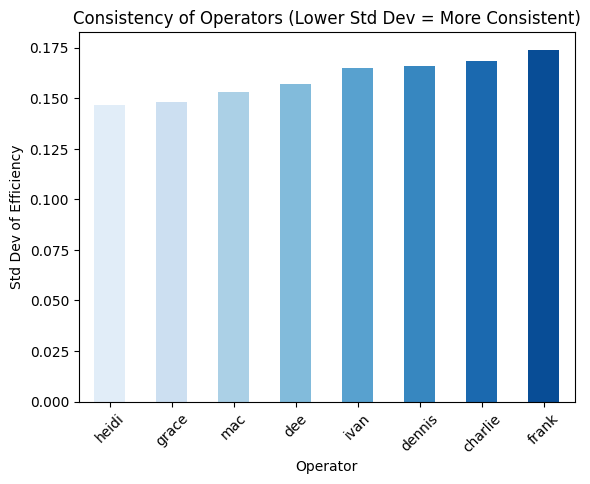

In [49]:
# Who is the most consistent operator, based on the lowest standard deviation in efficiency_ratio?
operator_std = df.groupby('Operator')['Efficiency'].std().sort_values()
operator_std.plot(kind='bar', color=sns.color_palette("Blues", len(operator_std)))
plt.xlabel('Operator')
plt.ylabel('Std Dev of Efficiency')
plt.title('Consistency of Operators (Lower Std Dev = More Consistent)')
plt.xticks(rotation=45)
plt.show()

Text(0.5, 1.0, 'Average Performance Loss by Product')

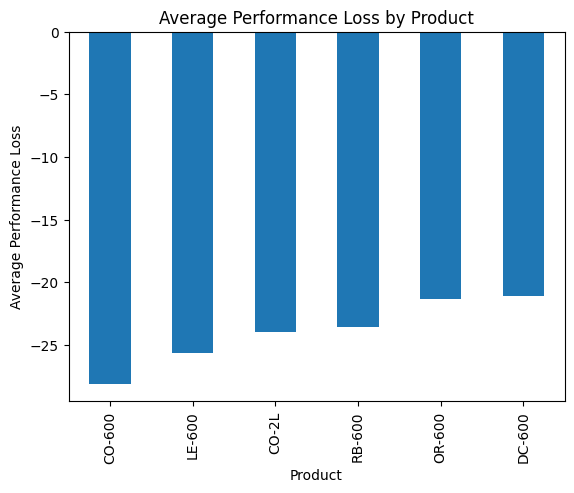

In [56]:
df.groupby("Product")["Performance_loss"].mean().sort_values().plot(kind='bar')
plt.xlabel('Product')
plt.ylabel('Average Performance Loss')
plt.title('Average Performance Loss by Product')

<Axes: ylabel='Operator'>

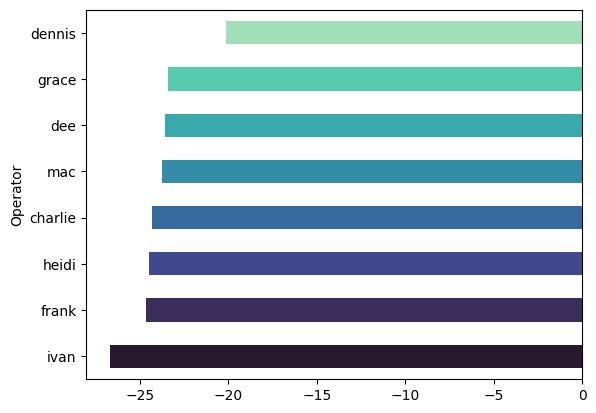

In [57]:
df.groupby("Operator")['Performance_loss'].mean().sort_values().plot(kind='barh', color=sns.color_palette("mako", len(df['Operator'].unique())))

<Axes: ylabel='Description'>

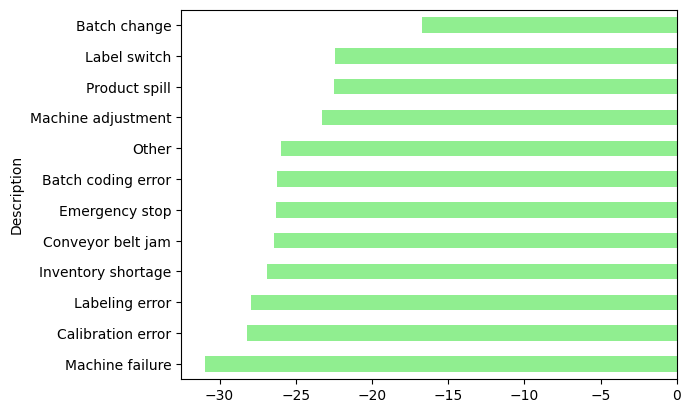

In [58]:
df.groupby("Description")['Performance_loss'].mean().sort_values().plot(kind='barh', color='lightgreen')

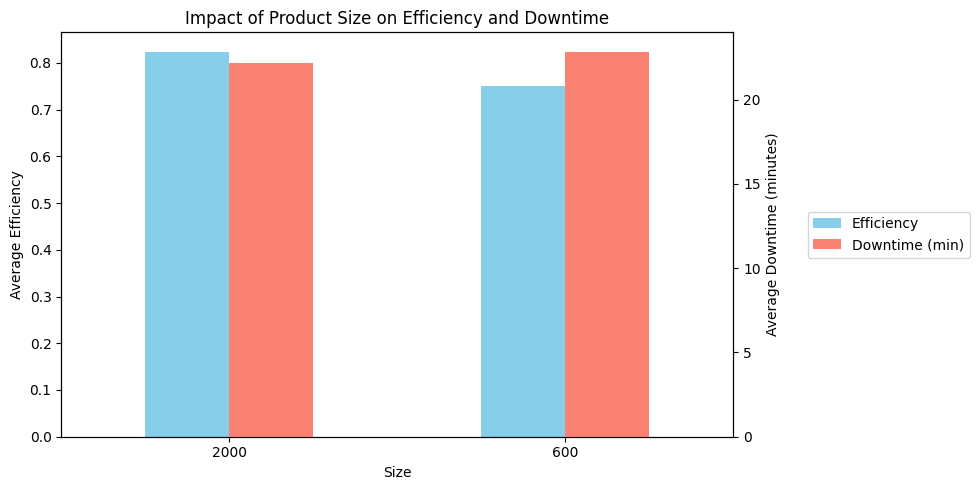

In [61]:
from matplotlib.patches import Patch

size_analysis = df.groupby('Size')[['Efficiency', 'Downtime_Minutes']].mean().sort_values(by='Efficiency', ascending=False)
# let pandas return the axes object so we can access the secondary axis via ax.right_ax
ax = size_analysis.plot(kind='bar', secondary_y='Downtime_Minutes', color=['skyblue', 'salmon'], figsize=(10,5),legend=False)
ax.set_xlabel('Size')
ax.set_ylabel('Average Efficiency')
ax.set_title('Impact of Product Size on Efficiency and Downtime')
# set label for the secondary (right) y-axis
ax.right_ax.set_ylabel('Average Downtime (minutes)')
# keep x tick labels horizontal
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
handles = [Patch(facecolor='skyblue', label='Efficiency'), Patch(facecolor='salmon', label='Downtime (min)')]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.tight_layout()
plt.show()

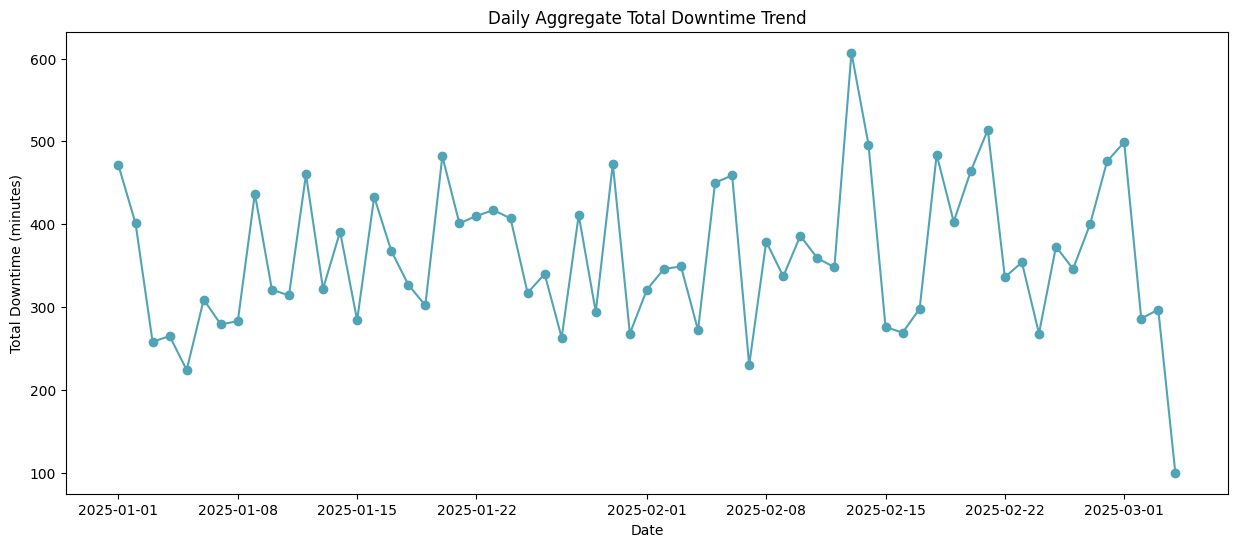

In [69]:
# تحويل العمود Date إلى datetime
df['Date'] = pd.to_datetime(df['Date'])

# حساب إجمالي Downtime لكل يوم
daily_downtime = df.groupby('Date')['Downtime_Minutes'].sum().sort_index()

# رسم Time-Series Line Chart
plt.figure(figsize=(15,6))
plt.plot(daily_downtime.index, daily_downtime.values, color="#50A4B5", marker='o')
plt.xlabel('Date')
plt.ylabel('Total Downtime (minutes)')
plt.title('Daily Aggregate Total Downtime Trend')
plt.show()

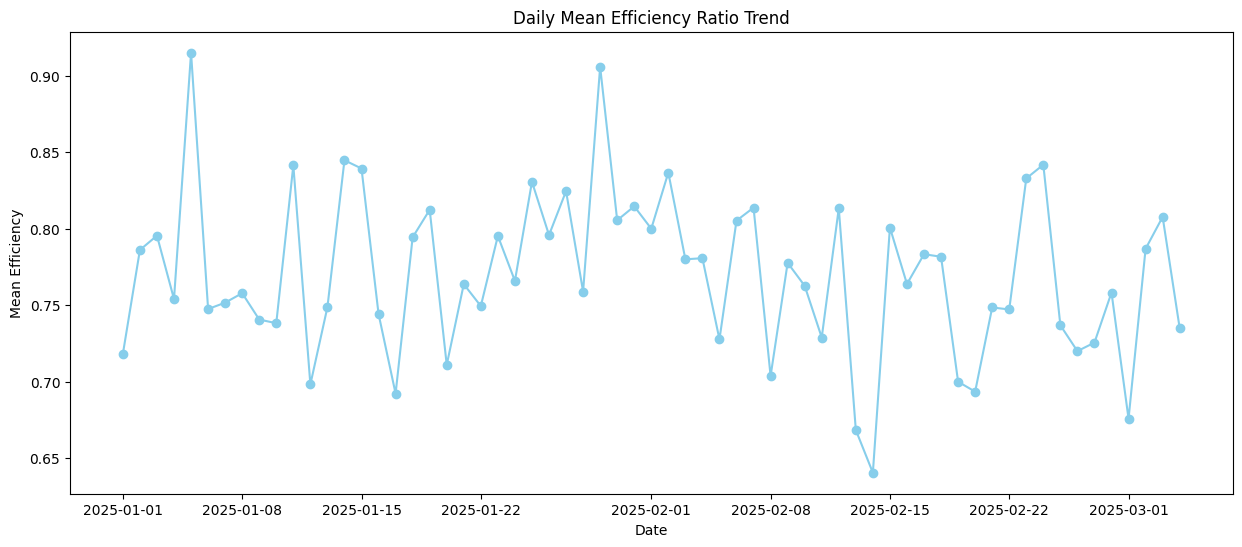

In [71]:
# حساب متوسط Efficiency لكل يوم
daily_efficiency = df.groupby('Date')['Efficiency'].mean().sort_index()

# رسم Time-Series Line Chart
plt.figure(figsize=(15,6))
plt.plot(daily_efficiency.index, daily_efficiency.values, color='skyblue', marker='o')
plt.xlabel('Date')
plt.ylabel('Mean Efficiency')
plt.title('Daily Mean Efficiency Ratio Trend')
plt.show()

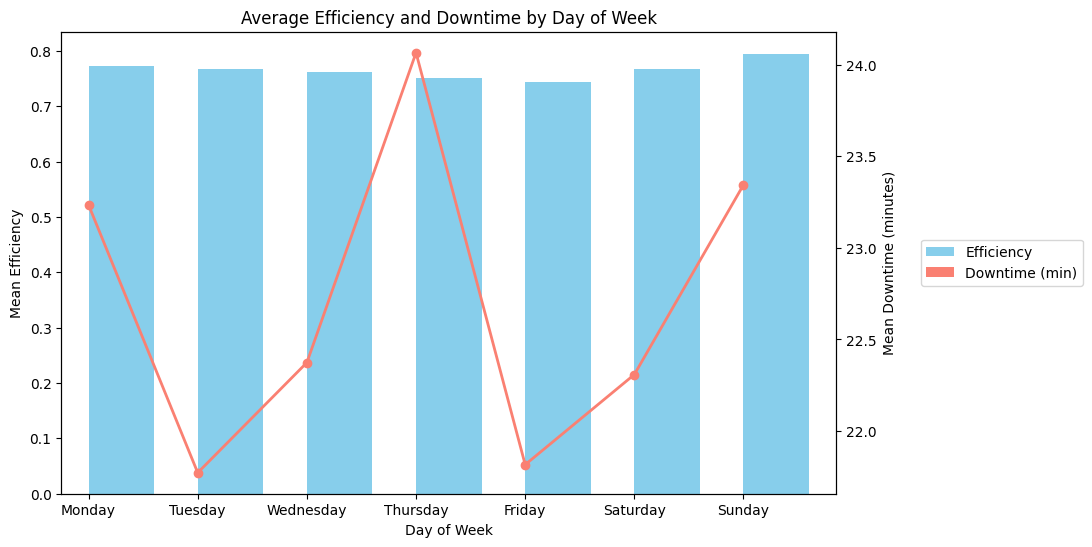

In [74]:
# استخراج يوم الأسبوع (0 = Monday, 6 = Sunday)
df['Day_of_Week'] = df['Date'].dt.day_name()  # يعطي اسم اليوم مباشرة

# حساب متوسط Efficiency و Downtime لكل يوم
dow_day_analysis = df.groupby('Day_of_Week')[['Efficiency', 'Downtime_Minutes']].mean()

# ترتيب الأيام حسب التسلسل الأسبوعي
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_day_analysis = dow_day_analysis.reindex(dow_order)

# رسم: نرسم Efficiency كأعمدة ونرسم Downtime على المحور الثانوي كخط لتفادي مشكلات right_ax
ax = dow_day_analysis['Efficiency'].plot(kind='bar', color='skyblue', figsize=(10,6), width=0.6, position=0)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Mean Efficiency')

# إنشاء محور ثانوي باستخدام twinx() ثم رسم Downtime عليه (كمخط)
ax2 = ax.twinx()
dow_day_analysis['Downtime_Minutes'].plot(kind='line', ax=ax2, color='salmon', marker='o', linewidth=2)
ax2.set_ylabel('Mean Downtime (minutes)')
handles = [Patch(facecolor='skyblue', label='Efficiency'), Patch(facecolor='salmon', label='Downtime (min)')]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.title('Average Efficiency and Downtime by Day of Week')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()

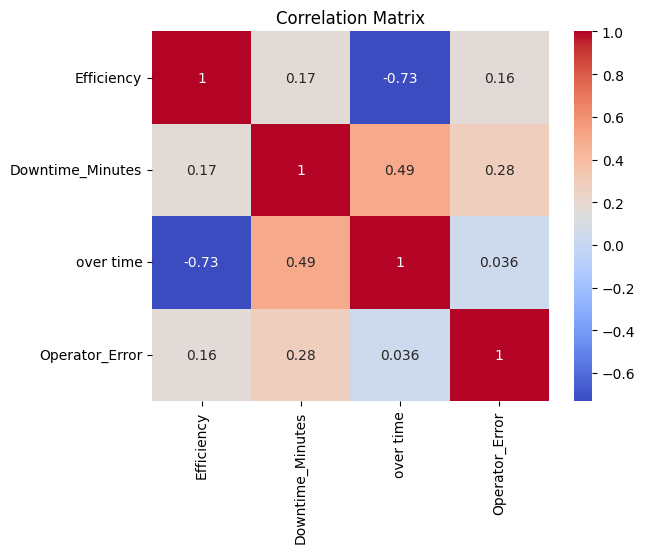

In [84]:
df[['Efficiency','Downtime_Minutes','over time','Operator_Error']].corr()
sns.heatmap(df[['Efficiency','Downtime_Minutes','over time','Operator_Error']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

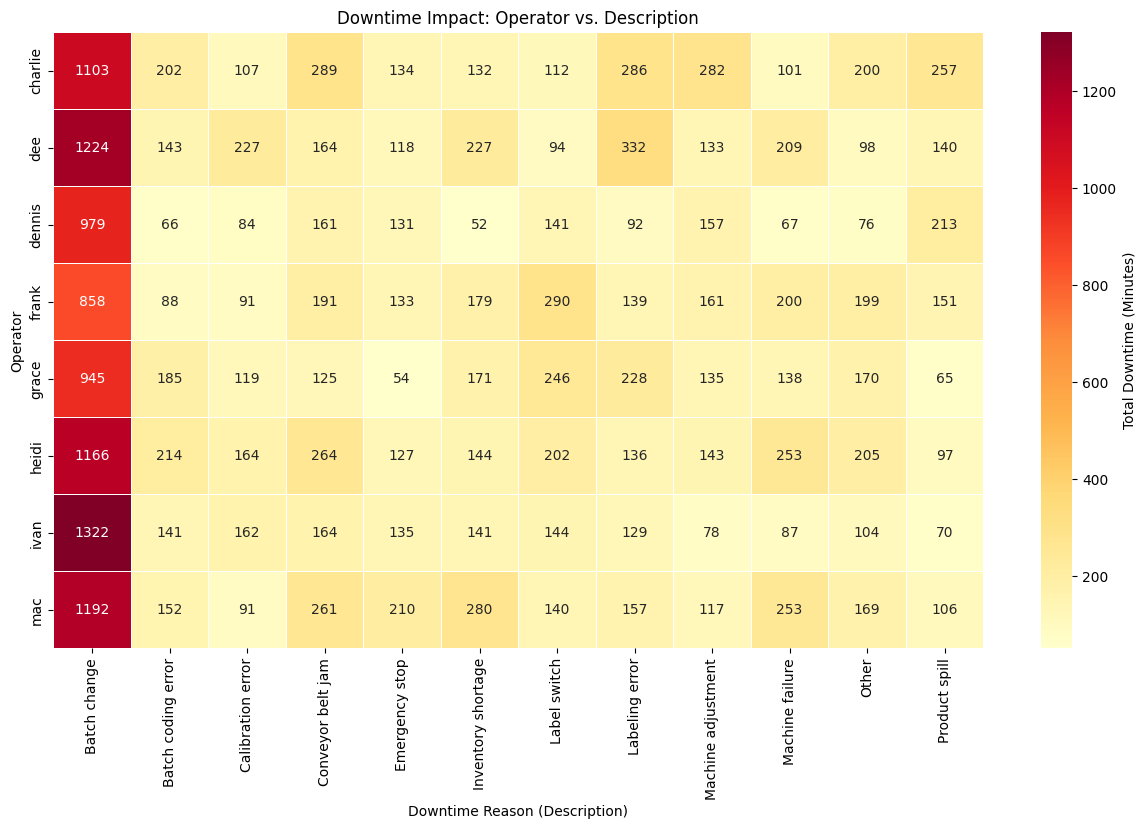

In [59]:
downtime_pivot = df.pivot_table(
    index='Operator',
    columns='Description',
    values='Downtime_Minutes',
    aggfunc='sum' # نجمع دقائق التوقف
)

# 2. إنشاء خريطة الحرارة
plt.figure(figsize=(15, 8))
sns.heatmap(
    downtime_pivot,
    annot=True,    # لإظهار الأرقام داخل الخلايا
    fmt=".0f",     # تنسيق الأرقام كأعداد صحيحة
    cmap="YlOrRd", # تدرج لوني من الأصفر (قليل) إلى الأحمر الداكن (كثير)
    linewidths=.5, # خطوط فاصلة
    cbar_kws={'label': 'Total Downtime (Minutes)'}
)
plt.title('Downtime Impact: Operator vs. Description')
plt.ylabel('Operator')
plt.xlabel('Downtime Reason (Description)')
plt.show()

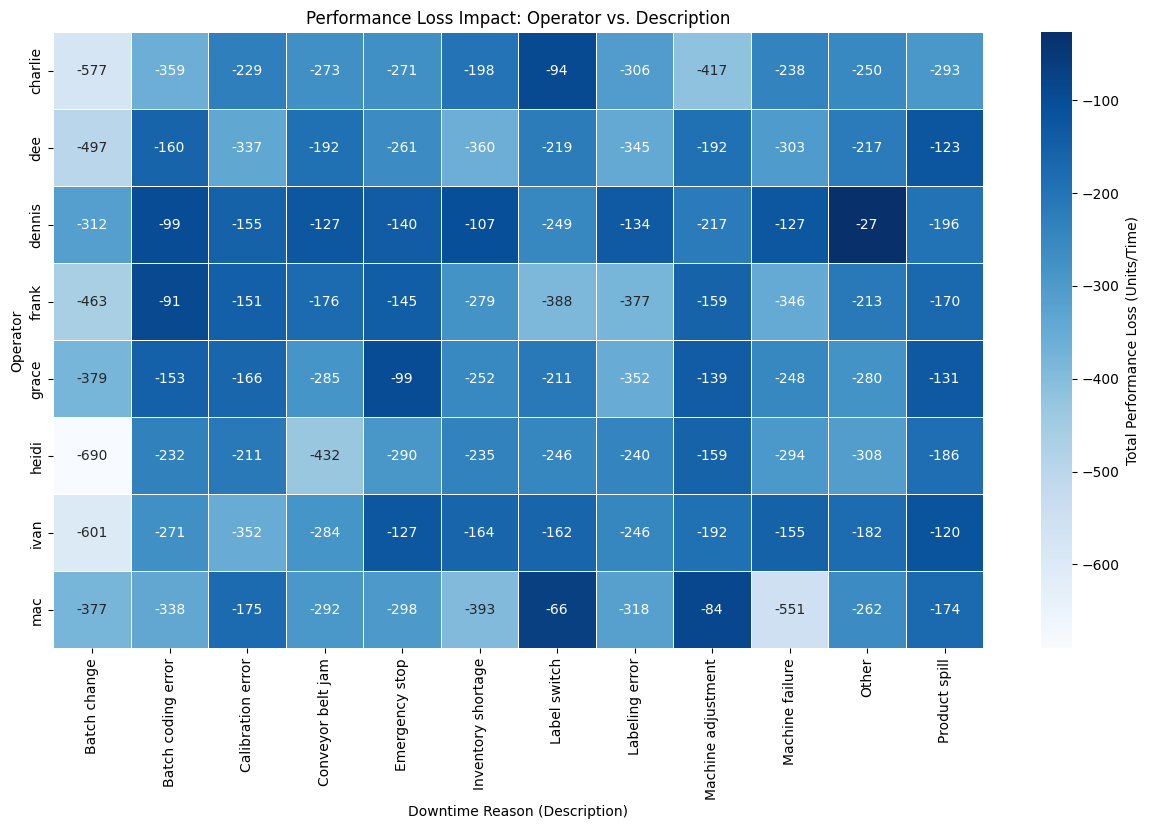

In [60]:
loss_pivot = df.pivot_table(
    index='Operator',
    columns='Description',
    values='Performance_loss', # العمود الجديد
    aggfunc='sum'
)

# 2. إنشاء خريطة الحرارة
plt.figure(figsize=(15, 8))
# نستخدم cmap مختلف قد يكون أزرق/أبيض
sns.heatmap(
    loss_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues", # تدرج لوني يعبر عن "الخسارة" (Loss)
    linewidths=.5,
    cbar_kws={'label': 'Total Performance Loss (Units/Time)'}
)
plt.title('Performance Loss Impact: Operator vs. Description')
plt.ylabel('Operator')
plt.xlabel('Downtime Reason (Description)')
plt.show()

In [8]:
# Save the processed DataFrame to a new Excel file
df.to_excel("Final.xlsx", index=False)